**Introduction:**

This notebook aims to provide a data driven argument in support of the "best" neighborhood in Pittsburgh. We began the process by identifying a number of features the average person would be looking for when chosing where to live. This includes features like traffic, safety, restaurants, cost, etc. From there, we chose a feature to focus on based on data availability and our own judgement on importance. We chose satefy as our metric for "best" neighborhood.

**Metric:**

Safety:

1. Criminal Activity: Number of Crimes Comitted by Neighborhood

2. Medical Services

3. Facilities: Facilities include buildings such as storage, shetler, activity, and restrooms. The data was from the Western Pennsylvania regional data center in the dataset: City of Pittsburgh Facilities

(Expand on this)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Criminal Activity

In [3]:
# CSV containing number of crimes comitted by neighborhood
criminalData = pd.read_csv("crimedata.csv", index_col="_id", low_memory=False)
# find just the number of crimes per neighborhood
crimecount = criminalData["Neighborhood"].value_counts()
df_crimes = crimecount.to_frame()
print(df_crimes.sort_values(by="count", ascending = False))

                           count
Neighborhood                    
Central Business District   9132
South Side Flats            5681
Carrick                     2814
East Liberty                2437
Shadyside                   2390
...                          ...
Chartiers                     49
Ridgemont                     40
Saint Clair                   25
St. Clair                     12
Chartiers City                 5

[94 rows x 1 columns]


This shows the number of crimes comitted in ech neighborhood, but some neighborhoods are a lot more populated than others, so we should include population data as well

In [8]:
# get population data
population = pd.read_csv("population.csv", index_col="Neighborhood",low_memory=False)
df_population = population.iloc[:,0:12:11].drop("_id", axis=1)

# merge crime and population frames
df_crimepopulation = df_population.merge(df_crimes, on="Neighborhood").sort_values(by = "count", ascending = False)
df_crimepopulation["Per capita"] = df_crimepopulation["count"] / df_crimepopulation["2020_Total_Population"]
df_crimepopulation.sort_values(by="Per capita").head(15)

,2020_Total_Population,count,Per capita
Neighborhood,,,
Chartiers City,492,5,0.010163
Swisshelm Park,1339,76,0.056759
Stanton Heights,4427,270,0.060989
St. Clair,183,12,0.065574
Squirrel Hill North,11879,780,0.065662
New Homestead,917,61,0.066521
Morningside,3252,242,0.074416
Westwood,3332,268,0.080432
North Oakland,10691,989,0.092508


Looking better; let's see a graph

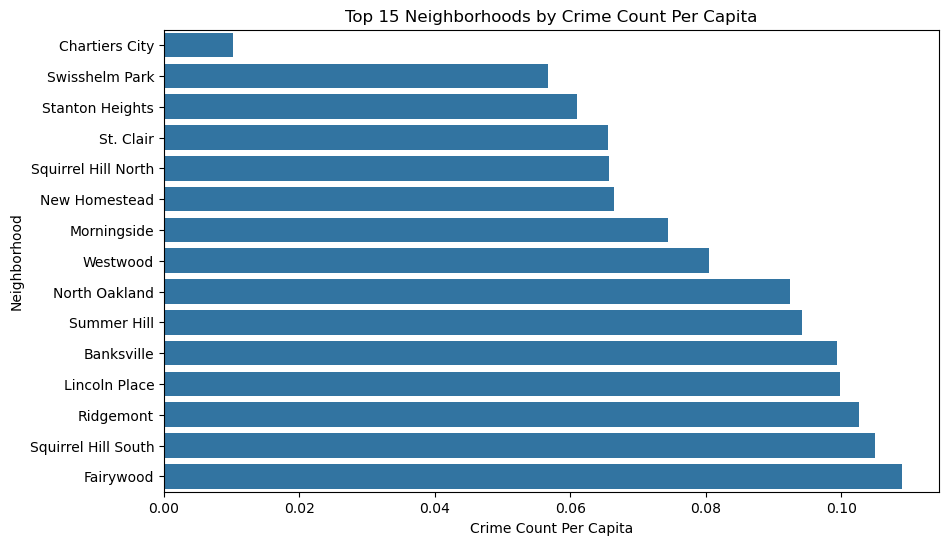

In [9]:
# Plot top 15 neighborhoods by crime count
top15 = df_crimepopulation.nsmallest(15, 'Per capita')
plt.figure(figsize=(10, 6))
sns.barplot(data=top15, x='Per capita', y='Neighborhood')
plt.title('Top 15 Neighborhoods by Crime Count Per Capita')
plt.xlabel('Crime Count Per Capita')
plt.ylabel('Neighborhood')
plt.show()

Chartiers City looks wonderful compared to everything else, but it has quite a small population. Squirrel Hill North and South in addtion to North Oakland look the best, since their populations are very high compared to neighborhoods of similar crimes per capita.

The *best neighborhood* title will be given to **Squirrel Hill North** for having a high population and a very low crime count compared to it.

## Medical Services

In [2]:
df_ems = pd.read_csv("emergencymedicalservices.csv")
df_ems.head()

,_id,objectid,area,perimeter,rams,rams_id,acres,sqmiles,district,shape_area,shape_length
0,5677,1,1.089535e+08,65491.364725,60,915,2501.229980,3.91,4,1.089535e+08,65491.366021
1,5678,2,2.859605e+07,39150.158174,86,786,656.469971,1.03,9,2.859605e+07,39150.158189
2,5679,3,1.006612e+08,76786.588197,103,762,2310.860107,3.61,11,1.006612e+08,76786.588221
3,5680,4,7.606783e+07,44022.611587,105,836,1746.280029,2.73,5,7.606784e+07,44022.612805
4,5681,5,1.501305e+08,71746.234269,160,818,3446.520020,5.39,7,1.501305e+08,71746.234309


In [3]:
district_counts = df_ems['district'].value_counts().reset_index()
district_counts.columns = ['District', 'Count']

district_counts
#count the districts
#District 12 → 4 zones  
#District 1, 14, 10, 6 : 2 zones each  
#Others : only 1 zone

,District,Count
0,12,4
1,1,2
2,14,2
3,10,2
4,6,2
5,7,1
6,5,1
7,11,1
8,9,1
9,4,1


In [4]:
district_area = df_ems.groupby('district')['sqmiles'].sum().reset_index()

district_area = district_area.sort_values(by='sqmiles')

district_area
#analyze coverage; smaller area = faster response 
#District 12 has the most subdivisions (4)
#BUT still covers a large total area (5.78)

,district,sqmiles
8,9,1.03
12,14,1.48
7,8,2.49
4,5,2.73
10,11,3.61
3,4,3.91
0,1,4.14
5,6,4.77
9,10,4.90
6,7,5.39


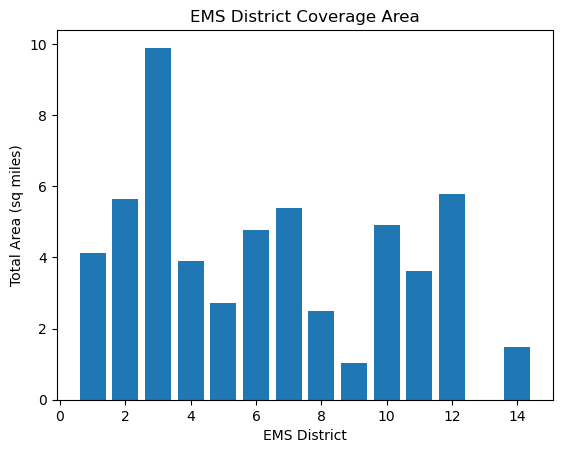

In [5]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(district_area['district'], district_area['sqmiles'])
plt.xlabel("EMS District")
plt.ylabel("Total Area (sq miles)")
plt.title("EMS District Coverage Area")
plt.show()

For my analysis, I examined Emergency Medical Service districts in Pittsburgh and evaluated how coverage area impacts response efficiency. I grouped the data by district and calculated the total area each district covers in square miles. Districts that cover smaller areas are likely able to respond more quickly to emergencies, while larger districts may experience slower response times. This suggests that areas within smaller EMS districts may have better emergency response coverage, which contributes to overall safety.

## Facilities

In [2]:
# CSV containing facilities and their corresponding neighborhoods
df_facilities = pd.read_csv('https://data.wprdc.org/datastore/dump/fbb50b02-2879-47cd-abea-ae697ec05170')
# CSV containing information about neighborhoods including area
df_area = pd.read_csv('https://data.wprdc.org/datastore/dump/668d7238-cfd2-492e-b397-51a6e74182ff')

In [18]:
# Get the neighborhood and square miles isolated
area = df_area[['hood','sqmiles']]
area.columns = ['neighborhood', 'sqmiles']
print(area.sort_values(by='sqmiles', ascending=False))

                neighborhood   sqmiles
80       Squirrel Hill South  2.676605
24                 Brookline  2.088930
21  Lincoln-Lemington-Belmar  1.818101
25                      Hays  1.745098
51                   Carrick  1.669530
..                       ...       ...
32            Allegheny West  0.144794
50            Chartiers City  0.134015
18         Arlington Heights  0.127234
41                Friendship  0.106191
67                Mt. Oliver  0.103298

[90 rows x 2 columns]


In [19]:
# Get the neighborhood and number of facilities isolated
counts_df = df_facilities['neighborhood'].value_counts().reset_index()
counts_df.columns = ['neighborhood', 'num_facilities']
print(counts_df)

            neighborhood  num_facilities
0          Highland Park              30
1    Squirrel Hill South              29
2            Perry North              20
3              Brookline              19
4         Strip District              15
..                   ...             ...
70            Glen Hazel               1
71               Larimer               1
72  California-Kirkbride               1
73    Point Breeze North               1
74           Middle Hill               1

[75 rows x 2 columns]


In [20]:
# Merge the two dataframes and calculate the number of facilies per mile
final_df = pd.merge(counts_df, area[['neighborhood', 'sqmiles']], on='neighborhood', how='inner')
final_df['density'] = final_df['num_facilities'] / final_df['sqmiles']
#final_df = final_df.sort_values('density', ascending=False)
final_df = final_df.sort_values('num_facilities', ascending=False)
final_df.head(10)


,neighborhood,num_facilities,sqmiles,density
0,Highland Park,30,1.169860,25.644092
1,Squirrel Hill South,29,2.676605,10.834619
2,Perry North,20,1.209913,16.530114
3,Brookline,19,2.088930,9.095567
4,Strip District,15,0.608189,24.663404
5,Hazelwood,14,1.605243,8.721423
6,Brighton Heights,14,1.117022,12.533321
7,Carrick,12,1.669530,7.187652
8,Lincoln-Lemington-Belmar,11,1.818101,6.050268
9,South Side Slopes,11,0.723060,15.213119


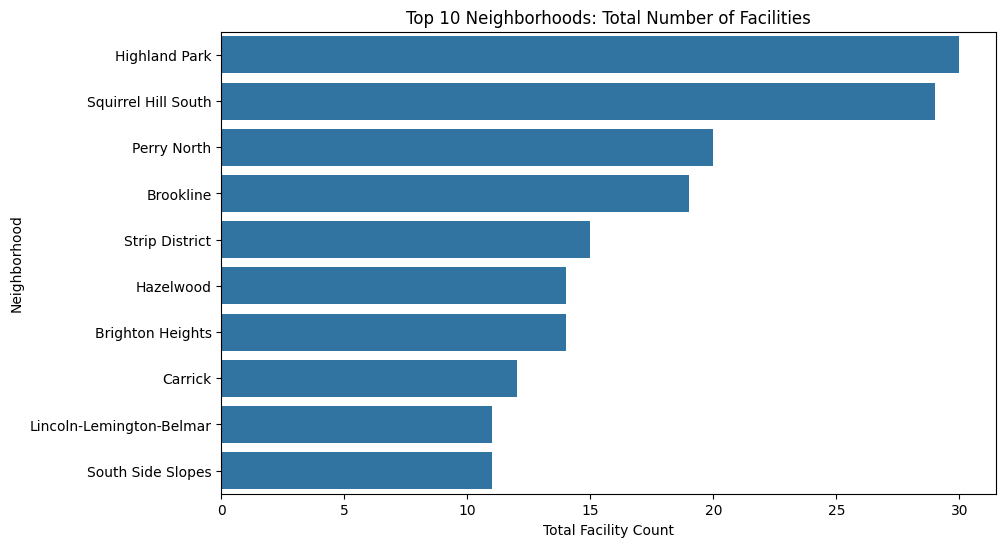

In [26]:
# Plot top ten neighborhoods by facilites
top_10_total = final_df.nlargest(10, 'num_facilities')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_total, x='num_facilities', y='neighborhood')
plt.title('Top 10 Neighborhoods: Total Number of Facilities')
plt.xlabel('Total Facility Count')
plt.ylabel('Neighborhood')
plt.show()

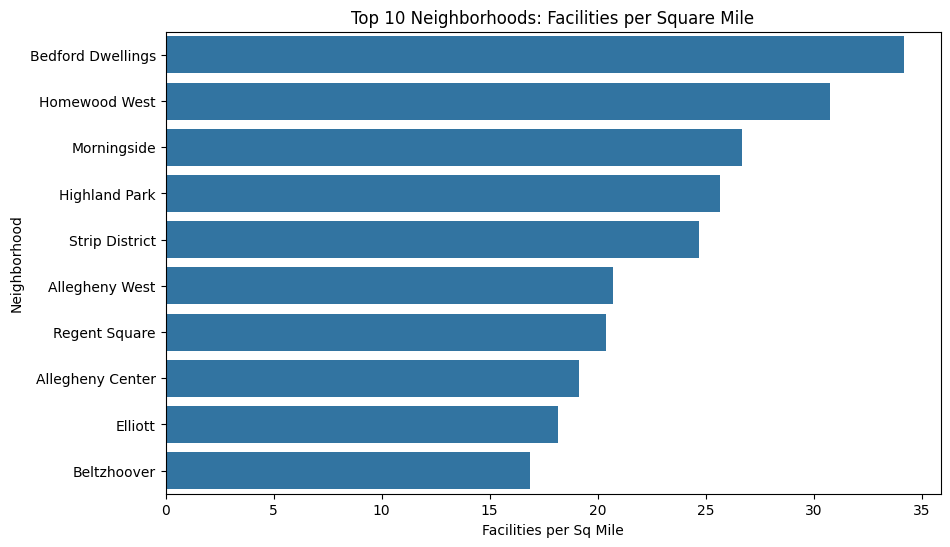

In [23]:
# Plot top ten neighborhoods by facilites per square mile
top_10_density = final_df.nlargest(10, 'density')
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10_density, x='density', y='neighborhood')
plt.title('Top 10 Neighborhoods: Facilities per Square Mile')
plt.xlabel('Facilities per Sq Mile')
plt.ylabel('Neighborhood')
plt.show()

**Best Neighborhood According to Facilities:**

Facilities often correlate with more safety because they create gather spaces, increase supervision, keep areas well maintained. Examples of facilities include libraries, rec centers, parks, and police/fire stations. I evaluated this data in two ways: total facilities and facilities per square mile. I found, however, that some areas were so small that they skewed the results of facilities per mile. So, based on the total facilities, Highland Park is the best neighborhood.

## Conclusion

Overall: After evaluating each of our three specific metrics, we believe we can combine them to form an overarching safety metric. Based on this overarching metric, we think Squirrel Hill South is the safest neighborhood.

Luke: The list of neighborhoods based on total facilities is quite close to what I think are some of the best neighborhoods. My personal favorite is Shadyside though there are not as many facilities there. I also enjoy Highland Park which was first, slightly validating the findings.

Henry: Squirrel Hill North and North Oakland are both very solid contenders due to their proportionally large populations compared to their crime count. Since Squirrel Hill North has the lower crime count, I choose it as the best neighborhood according to the crime count metric, since the other neighborhoods with similar or lower crime counts per capita have a much lower population. Chartiers City is also a strange outlier as there were only 5 crimes reported there, a result that I 

Adiva: The best neighborhood in terms of medical services was measured by amount of services in proportion to the area of the district. An area that has lots of people may find it harder to locate a medical service rather than a neighborhood with a smaller area in square miles. I concluded that Shadyside was the best neighborhood when measuring medical services. Its square miles and number of services when compared turned out to be the most convenient, contributing to overall safety. 